The content of Exercise 1 will be updated and refined as I continue my studies, with the final practical material ultimately encompassing more material. Additionally, certain aspects remain undetermined, so further revisions and improvements will be made.--By Yihan Shen

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


# 1. data preparation (Task 1)
# from rc_Q_V.txt
### I entered the data from the rc_Q_V.txt file directly into the code, making it convenient to run without needing to locate the file and repeatedly read it.
h_data = np.array([46.8, 45.3, 40.1, 40.1, 56.9, 29.9, 29.9, 32.3, 32.3, 23.7, 23.7])
q_data = np.array([2039, 1557, 1291.7, 1298.2, 2639.5, 420.7, 433.5, 559, 501.6, 266.6, 265.8])

# transfer to log form (Model: log(q) = a + b * log(h))
# regarding eq1 and eq2
log_h = np.log(h_data)
log_q = np.log(q_data)  # our observed vector Y
nd = len(h_data)

# construct design matrix A (dimensions: 11 x 2)
# the first column is 1 (i.e. a)，the second column is log(h) (i.e. b)
A = np.vstack([np.ones(nd), log_h]).T

# construct covariance matrix of noise: Gamma
# noticing Gamma_ii = 0.03 * log(q_i)
# 注意：通常协方差矩阵对角线是方差。这里我们严格按照题目定义 Gamma_ii
gamma_diag = 0.03 * log_q
Gamma = np.diag(gamma_diag)
Gamma_inv = np.linalg.inv(Gamma) # 提前计算逆矩阵用于解析解

print(f"number of datapoints: {nd}")
print("Shape of Design Matrix A :", A.shape)

number of datapoints: 11
Shape of Design Matrix A : (11, 2)


In [2]:

# Task2. Analytical Solution

# corresponding eq(6) 和 eq(7)

# Prior parameters
m0 = np.array([0, 0])      # prior mean
Sigma0 = np.array([[10, 0], [0, 10]]) # prior covariance
Sigma0_inv = np.linalg.inv(Sigma0)

# caculating posterior covariance Sigma (eq7)
# Sigma_post = (Sigma0^-1 + A^T * Gamma^-1 * A)^-1
Sigma_post = np.linalg.inv(Sigma0_inv + A.T @ Gamma_inv @ A)

# caculating posterior mean (eq 6)
# m_post = Sigma_post * (Sigma0^-1 * m0 + A^T * Gamma^-1 * Y)
m_post = Sigma_post @ (Sigma0_inv @ m0 + A.T @ Gamma_inv @ log_q)

print("-" * 30)
print("analytical solution")
print(f"posterior mean a (intercept): {m_post[0]:.4f}")
print(f"posterior mean b (slope)    : {m_post[1]:.4f}")
print(f"posterior covariance matrix (big sigma):\n{Sigma_post}")
print("-" * 30)



------------------------------
analytical solution
posterior mean a (intercept): -2.5637
posterior mean b (slope)    : 2.5826
posterior covariance matrix (big sigma):
[[ 2.35805922 -0.66433955]
 [-0.66433955  0.18859052]]
------------------------------


In [3]:
# 3. MCMC algorithm implement (Task 3 & 4)

def get_log_prior(x):
    """caculating log probability of prior"""
    return stats.multivariate_normal.logpdf(x, mean=m0, cov=Sigma0)

def get_log_likelihood(x):
    """caculating log probability of likelihood"""
    # prediction = a + b * log(h)
    predictions = A @ x
    # likelihood : prediction log_q~ N(predictions, Gamma)
    return stats.multivariate_normal.logpdf(log_q, mean=predictions, cov=Gamma)

def get_log_posterior(x):
    """posterior = prior + likelihood (after log)"""
    return get_log_prior(x) + get_log_likelihood(x)

# set RWM parameters
N_samples = 10000      # number of samples
x_start = np.array([0.0, 0.0]) # initial point (start from 0)

# variance of proposoed distribution (Task6: sigma^2 = 0.06^2)
proposal_sigma = 0.06
proposal_cov = (proposal_sigma**2) * np.eye(2)

# loop
chain = np.zeros((N_samples, 2))
chain[0] = x_start
current_log_prob = get_log_posterior(x_start)
accepted = 0

for i in range(1, N_samples):
    # 1. Propose: Take one random step
    current_x = chain[i-1]
    perturbation = np.random.multivariate_normal([0, 0], proposal_cov)
    proposed_x = current_x + perturbation

    # 2. Evaluate: Calculate the probability of the new position
    proposed_log_prob = get_log_posterior(proposed_x)

    # 3. Ratio: Calculate acceptance rate (log(p_new) - log(p_old))
    log_acceptance_ratio = proposed_log_prob - current_log_prob

    # 4. Decide: Metropolis
    # Generate a random number u (between 0 and 1), then compare log(u) and log_ratio
    if np.log(np.random.rand()) < log_acceptance_ratio:
        chain[i] = proposed_x
        current_log_prob = proposed_log_prob
        accepted += 1
    else:
        chain[i] = current_x # Reject, remain at this position

print(f"MCMC result:")
print(f"Acceptance Rate: {accepted / N_samples:.2%}") #The ideal acceptance rate typically ranges between 20% and 40%

MCMC result:
Acceptance Rate: 55.66%


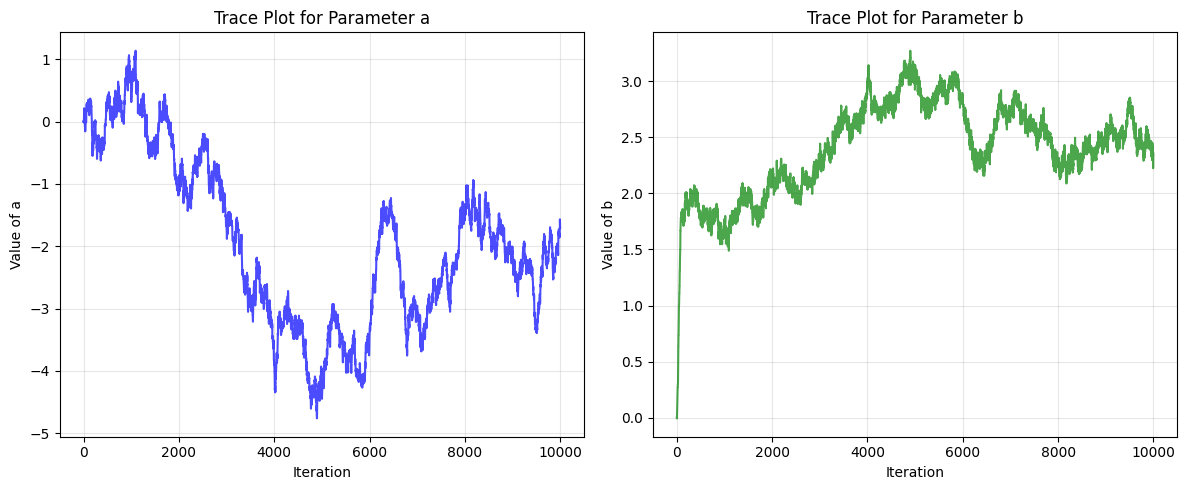

In [4]:
# 4. Visualisation of Results and Burn-in analysis (Task6)

# Trace Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(chain[:, 0], label='Parameter a', color='blue', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('Value of a')
plt.title('Trace Plot for Parameter a')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(chain[:, 1], label='Parameter b', color='green', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('Value of b')
plt.title('Trace Plot for Parameter b')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

------------------------------
remove the preceding 2000 steps (Burn-in) results then get:
MCMC Mean a: -2.4600 (analytical solution: -2.5637)
MCMC Mean b: 2.5540 (analytical solution: 2.5826)


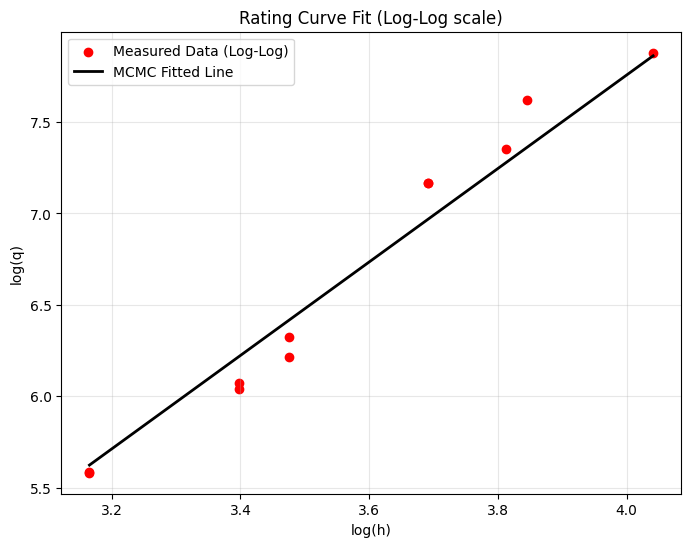

In [5]:
#Task 6: Burn-in analysis
# We typically discard the first 1000–2000 steps, as the chain is highly unlikely to have converged by that point
burn_in_period = 2000
clean_chain = chain[burn_in_period:, :]

print("-" * 30)
print(f"remove the preceding {burn_in_period} steps (Burn-in) results then get:")
mcmc_mean = np.mean(clean_chain, axis=0)
print(f"MCMC Mean a: {mcmc_mean[0]:.4f} (analytical solution: {m_post[0]:.4f})")
print(f"MCMC Mean b: {mcmc_mean[1]:.4f} (analytical solution: {m_post[1]:.4f})")

# plotting comparision
plt.figure(figsize=(8, 6))
plt.scatter(log_h, log_q, color='red', label='Measured Data (Log-Log)')
x_range = np.linspace(min(log_h), max(log_h), 100)
y_pred = mcmc_mean[0] + mcmc_mean[1] * x_range
plt.plot(x_range, y_pred, color='black', linewidth=2, label='MCMC Fitted Line')
plt.xlabel('log(h)')
plt.ylabel('log(q)')
plt.title('Rating Curve Fit (Log-Log scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

=== Task 7 & 8: Sensitivity Analysis ===
1. Benchmark (Noise=0.03, Prop=0.06): Acceptance Rate = 31.20%
2. High Noise (Noise=1.0)         : Acceptance Rate = 95.94%
3. Low Noise (Noise=0.001)          : Acceptance Rate = 2.82%
4. Small Step (Prop=0.01, N=0.6)    : Acceptance Rate = 98.22% (Slow mixing)
5. Big Step (Prop=3.0, N=0.6)       : Acceptance Rate = 10.82%(stuck)


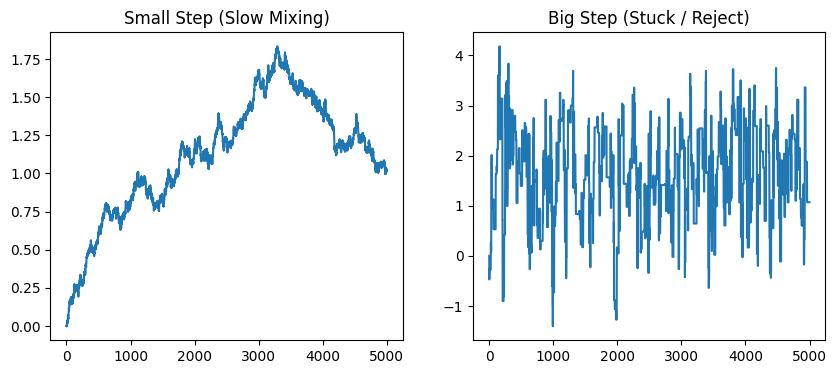

In [6]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# pre for data
h_data = np.array([46.8, 45.3, 40.1, 40.1, 56.9, 29.9, 29.9, 32.3, 32.3, 23.7, 23.7])
q_data = np.array([2039, 1557, 1291.7, 1298.2, 2639.5, 420.7, 433.5, 559, 501.6, 266.6, 265.8])
log_h = np.log(h_data)
log_q = np.log(q_data)
A = np.vstack([np.ones(len(h_data)), log_h]).T

# --- test different paprameters after packing those functions ---
def run_mcmc_experiment(noise_level_factor, proposal_sigma, steps=5000):
    """
    noise_level_factor: Control noise level (1.0 is the baseline 3%)
    proposal_sigma: Standard deviation of the proposed distribution
    """
    # 1. Adjust the noise matrix Gamma
    # base is 0.03 * log(q)，这里我们乘上一个因子来模拟 Task 7&8 的变化
    # Task 7  "noise level equal to 1"，将系数变为 1.0 (原为 0.03)
    current_noise_std = noise_level_factor * log_q
    Gamma = np.diag(current_noise_std**2)

    # 2. prior and likelihood
    m0 = np.array([0, 0])
    Sigma0 = np.array([[10, 0], [0, 10]])

    def get_log_posterior(x):
        log_prior = stats.multivariate_normal.logpdf(x, m0, Sigma0)
        predictions = A @ x
        log_like = stats.multivariate_normal.logpdf(log_q, predictions, Gamma)
        return log_prior + log_like

    # 3. running MCMC
    chain = np.zeros((steps, 2))
    x_curr = np.array([0.0, 0.0]) # Starting point
    chain[0] = x_curr
    lp_curr = get_log_posterior(x_curr)
    accepted = 0

    prop_cov = (proposal_sigma**2) * np.eye(2)

    for i in range(1, steps):
        x_prop = x_curr + np.random.multivariate_normal([0, 0], prop_cov)
        lp_prop = get_log_posterior(x_prop)

        if np.log(np.random.rand()) < (lp_prop - lp_curr):
            x_curr = x_prop
            lp_curr = lp_prop
            accepted += 1
        chain[i] = x_curr

    return chain, accepted / steps

# Task 7 & 8 test printing
print("=== Task 7 & 8: Sensitivity Analysis ===")

# test 1: base (Noise=0.03, Sigma=0.06)
chain_base, acc_base = run_mcmc_experiment(noise_level_factor=0.03, proposal_sigma=0.06)
print(f"1. Benchmark (Noise=0.03, Prop=0.06): Acceptance Rate = {acc_base:.2%}")

# test 2: when noise is too big (Noise=1.0) from Task 7
chain_high_noise, acc_high_noise = run_mcmc_experiment(noise_level_factor=1.0, proposal_sigma=0.06)
print(f"2. High Noise (Noise=1.0)         : Acceptance Rate = {acc_high_noise:.2%}")# Too high

# test 3: when noise is too small (Noise=0.001) -> Task 7
# 此时如果 Prop 还是 0.06，接受率会非常低
chain_low_noise, acc_low_noise = run_mcmc_experiment(noise_level_factor=0.001, proposal_sigma=0.06)
print(f"3. Low Noise (Noise=0.001)          : Acceptance Rate = {acc_low_noise:.2%}")# Too low

# test 4: when prposed step is too small (Prop=0.01) -> Task 8
chain_small_step, acc_small_step = run_mcmc_experiment(noise_level_factor=0.6, proposal_sigma=0.01) # Task 8 noise=0.6
print(f"4. Small Step (Prop=0.01, N=0.6)    : Acceptance Rate = {acc_small_step:.2%} (Slow mixing)")

# test 5: when prposed step is too big (Prop=3.0) -> Task 8
chain_big_step, acc_big_step = run_mcmc_experiment(noise_level_factor=0.6, proposal_sigma=3.0)
print(f"5. Big Step (Prop=3.0, N=0.6)       : Acceptance Rate = {acc_big_step:.2%}(stuck)")

# plotting for comparison (if test 4 VS 5)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(chain_small_step[:, 1])
plt.title("Small Step (Slow Mixing)")
plt.subplot(1, 2, 2)
plt.plot(chain_big_step[:, 1])
plt.title("Big Step (Stuck / Reject)")
plt.show()


=== Task 9: Quadratic Model (q = a + bh + ch^2) ===
Quadratic Analytical Mean: [  0.27508805 -15.20468073   1.05645052]
Parameters: a (intercept), b (linear), c (quadratic)
Quadratic MCMC Acceptance Rate: 70.25%


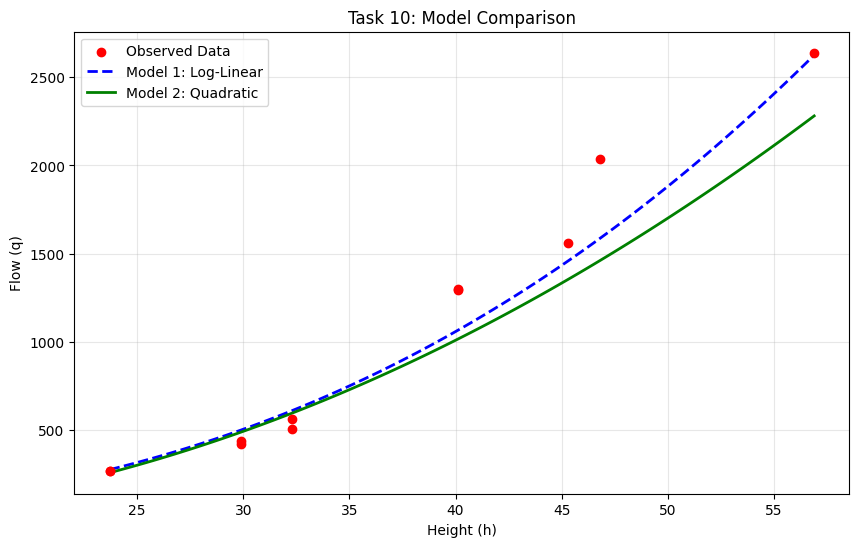

In [7]:
print("\n=== Task 9: Quadratic Model (q = a + bh + ch^2) ===")

# Matrix A : [1, h, h^2] 3 columns
A_quad = np.vstack([np.ones(len(h_data)), h_data, h_data**2]).T
nd = len(q_data)

# 2. noise setting
# 练习要求 log 模型用 log(q) 的 3%。线性模型里，我们假设噪声也是 q 的 3% (成比例噪声)
# Gamma diagnol = (0.03 * q)^2
Gamma_quad_diag = (0.03 * q_data)**2
Gamma_quad = np.diag(Gamma_quad_diag)
Gamma_quad_inv = np.linalg.inv(Gamma_quad)

# 3. analytical solution (eq 6,7 but dimensions changed)
# 先验变为 3 维
m0_quad = np.array([0, 0, 0])
Sigma0_quad = np.eye(3) * 10
Sigma0_quad_inv = np.linalg.inv(Sigma0_quad)

# caculating posterior
Sigma_post_quad = np.linalg.inv(Sigma0_quad_inv + A_quad.T @ Gamma_quad_inv @ A_quad)
m_post_quad = Sigma_post_quad @ (Sigma0_quad_inv @ m0_quad + A_quad.T @ Gamma_quad_inv @ q_data)

print(f"Quadratic Analytical Mean: {m_post_quad}")
print("Parameters: a (intercept), b (linear), c (quadratic)")

# 4.  MCMC (for Quadratic)
def get_log_posterior_quad(x):
    # x is [a, b, c]
    log_prior = stats.multivariate_normal.logpdf(x, m0_quad, Sigma0_quad)
    predictions = A_quad @ x
    log_like = stats.multivariate_normal.logpdf(q_data, predictions, Gamma_quad)
    return log_prior + log_like

# MCMC Loop
N_quad = 10000
chain_quad = np.zeros((N_quad, 3))
x_curr = np.array([0, 0, 0]) # Start
lp_curr = get_log_posterior_quad(x_curr)

# proposed variance : due to scale has big difference (h^2 too big), c will be small
prop_cov_quad = np.diag([1.0, 0.1, 0.001]) ** 2 # Adjust the step size according to the different orders of magnitude of the parameters.

accepted_quad = 0
for i in range(1, N_quad):
    x_prop = x_curr + np.random.multivariate_normal([0,0,0], prop_cov_quad)
    lp_prop = get_log_posterior_quad(x_prop)

    if np.log(np.random.rand()) < (lp_prop - lp_curr):
        x_curr = x_prop
        lp_curr = lp_prop
        accepted_quad += 1
    chain_quad[i] = x_curr

print(f"Quadratic MCMC Acceptance Rate: {accepted_quad/N_quad:.2%}")

# plotting: fitting results comparison
burn_in_q = 2000
mean_params_q = np.mean(chain_quad[burn_in_q:], axis=0)

# generating predicted curve
h_range = np.linspace(min(h_data), max(h_data), 100)
# Model 1 (Log-Linear)prediction (transfered to linear space q = exp(a + b*log(h)))
# m_post from task 6
# m_post[0]=a, m_post[1]=b
q_pred_model1 = np.exp(m_post[0] + m_post[1] * np.log(h_range))

# Model 2 (Quadratic) predictions
q_pred_model2 = mean_params_q[0] + mean_params_q[1]*h_range + mean_params_q[2]*h_range**2

plt.figure(figsize=(10, 6))
plt.scatter(h_data, q_data, color='red', label='Observed Data', zorder=5)
plt.plot(h_range, q_pred_model1, 'b--', linewidth=2, label='Model 1: Log-Linear')
plt.plot(h_range, q_pred_model2, 'g-', linewidth=2, label='Model 2: Quadratic')
plt.xlabel('Height (h)')
plt.ylabel('Flow (q)')
plt.title('Task 10: Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### by evaluating the rationality of model selection by comparing the fitting effects and parameter
## interpretability of the two models (logarithmic model and polynomial model).